# Autoencoder with grid cell auxiliary input

Same pipeline as `attention_notebook.ipynb` but with an additional input to the autoencoder, which is a grid cell representation of the position of the agent in the environment. The grid cell representation is generated by a separate module that takes the agent's position as input and outputs a grid cell representation and does not account for view angles. 
The autoencoder then takes both the image and the grid cell representation as input and tries to reconstruct BOTH inputs.

In [ ]:
import matplotlib.pyplot as plt
import torch
from torchvision.transforms import v2
from tqdm import tqdm
import numpy as np
import os

from grid_cells.encoder import GridCellEncoder, GridModule
from ae_model.cnn_hippocampal_ae import Conv_AE

from utils import build_dataloader, WebotsFrameDataset, set_seed
from attention_model.conv_encoder import ConvEncoder

from typing import Optional


print(f'PyTorch version: {torch.__version__}')
print('Numpy version:', np.__version__)

seed = 42
set_seed(seed)

feature_model_path = './attention_model/SAM_weights/'
checkpoint_path = './ae_model/feature_extractor_ae_checkpoint/grid/'
# images must be in the SAME dir as the csv file
webots_dataset_path = '../Denis/HIP_AE_VISUAL/Datasets/Tmaze_2/data.csv'

do_training = False

PyTorch version: 2.12.0+cu130
Numpy version: 2.4.6


### Estimate parameters from dataset


In [31]:
batch_size = 512
tf = v2.Compose([
    v2.ToDtype(torch.float32, scale=True),
    v2.Resize((248, 328)),
    v2.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
])


loader = build_dataloader(
    "../Denis/HIP_AE_VISUAL/Datasets/Tmaze_2/data.csv", 
    transform=tf, 
    batch_size=batch_size, 
    shuffle=True,
    num_workers=12, 
    seed=seed
)
images, xy = next(iter(loader))

print(xy.min() , xy.max())

tensor(-0.5935) tensor(0.5960)


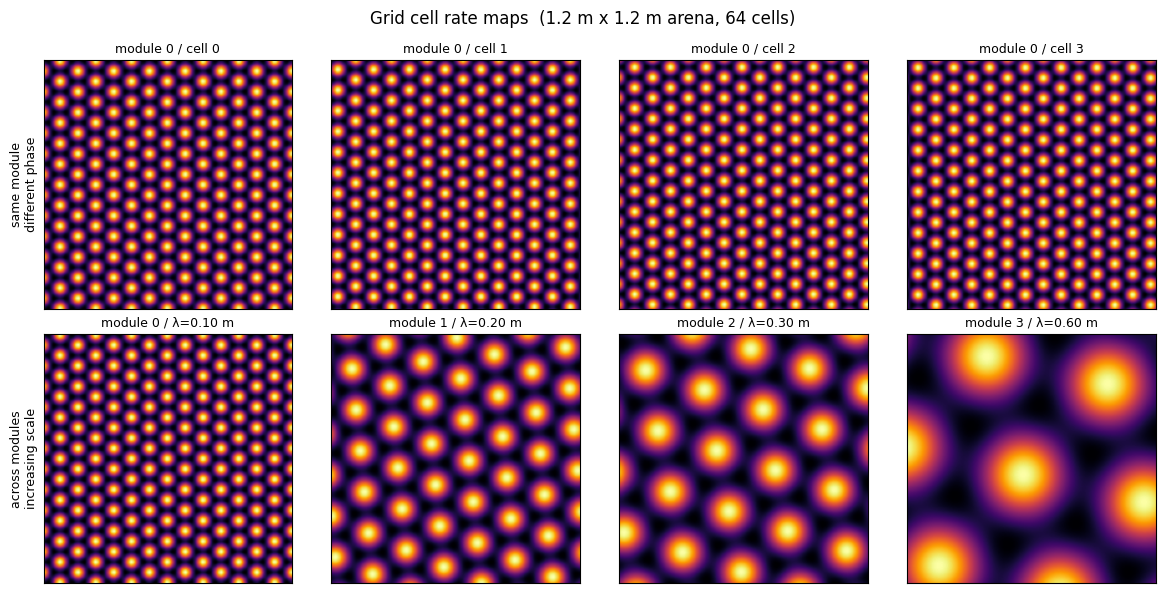

In [32]:

ARENA_SIZE = 1.2  # [m]
GRID_RES = 200  # samples per side
CELLS_PER_MODULE = 4

if do_training:
    gridcell_encoder = GridCellEncoder(
        [
            GridModule(scale=0.20, orientation=0.00, n_cells=CELLS_PER_MODULE),
            GridModule(scale=0.30, orientation=0.10, n_cells=CELLS_PER_MODULE),
            GridModule(scale=0.60, orientation=0.20, n_cells=CELLS_PER_MODULE),        
            GridModule(scale=0.80, orientation=0.30, n_cells=CELLS_PER_MODULE),
            GridModule(scale=1.0, orientation=0.40, n_cells=CELLS_PER_MODULE),
        ],
    )
else:
    from grid_cells.encoder import load_grid_encoder
    gridcell_encoder = load_grid_encoder(os.path.join(checkpoint_path, "grid_encoder.pt"), map_location="cpu")


g = torch.linspace(-ARENA_SIZE/2, ARENA_SIZE/2, GRID_RES)
X, Y = torch.meshgrid(g, g, indexing="xy")
pos = torch.stack([X.reshape(-1), Y.reshape(-1)], dim=1)

with torch.no_grad():
    rates = gridcell_encoder(pos).reshape(GRID_RES, GRID_RES, gridcell_encoder.n_cells)

# Row 0: four cells from module 0, different phase offsets
# Row 1: first cell of each module, increasing spatial scale
same_module_cells = list(range(CELLS_PER_MODULE))
across_module_cells = [0, 4,  8, 12]

fig, axes = plt.subplots(2, len(across_module_cells), figsize=(12, 6))
extent = [-ARENA_SIZE/2, ARENA_SIZE/2, -ARENA_SIZE/2, ARENA_SIZE/2]

for ax, c in zip(axes[0], same_module_cells):
    ax.imshow(rates[..., c].numpy(), origin="lower", extent=extent, cmap="inferno")
    ax.set_title(f"module 0 / cell {c}", fontsize=9)
    ax.set_xticks([])
    ax.set_yticks([])

for ax, c in zip(axes[1], across_module_cells):
    m = c // CELLS_PER_MODULE
    ax.imshow(rates[..., c].numpy(), origin="lower", extent=extent, cmap="inferno")
    ax.set_title(f"module {m} / \u03bb={gridcell_encoder.module_specs[m].scale:.2f} m", fontsize=9)
    ax.set_xticks([])
    ax.set_yticks([])

axes[0, 0].set_ylabel("same module\ndifferent phase", fontsize=9)
axes[1, 0].set_ylabel("across modules\nincreasing scale", fontsize=9)

fig.suptitle("Grid cell rate maps  (1.2 m x 1.2 m arena, 64 cells)")
fig.tight_layout()
fig.savefig("grid_rate_maps.png", dpi=120, bbox_inches="tight")
plt.show()

Mostly same pipeline as `attention_notebook.ipynb` but with an additional input to the autoencoder.

In [33]:
from utils import get_parameters, timer


# ------ params -----------------
n_hidden = 200
learning_rate = 5e-4
min_learning_rate = 1e-6
alpha = 1e5
C_factor = 1000.0
num_epochs = 1_000
beta = 0.5  # weight for the grid cell reconstruction loss


# ---- Feature extractor -----------------------------
ckpt = torch.load(feature_model_path + "best.ckpt", weights_only=False, map_location=torch.device('cpu'))

encoder_state_dict = ckpt["state_dict"]
# Fix: only delete the OLD key if it differs from the new one
for k in list(encoder_state_dict.keys()):
    new_k = k.replace("encoder.encoder", "encoder").replace("encoder.concept_proj", "concept_proj")
    if new_k != k:
        encoder_state_dict[new_k] = encoder_state_dict.pop(k)

feature_extractor = ConvEncoder()
feature_extractor.load_state_dict(ckpt["state_dict"])

# ---- Autoencoder ------------------------------
ae_model = Conv_AE(n_hidden=n_hidden, last_layer_activation=torch.nn.Sigmoid(), d_aux=gridcell_encoder.n_cells)
print(f"Number of parameters: {get_parameters(ae_model)} M")

# ---- optimizer ------------------------------
optimizer = torch.optim.Adam(ae_model.parameters(), lr=learning_rate)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=min_learning_rate)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")



Number of parameters: 0.399848 M
Using device: cuda


In [34]:
from training_functions import train_aux

if do_training:
    # training loop
    with timer("Training complete in: "):
        history = train_aux(
            feature_extractor=feature_extractor,
            grid_cell_encoder=gridcell_encoder,
            ae_model=ae_model,
            loader=loader,
            optimizer=optimizer,
            scheduler=scheduler,
            criterion=torch.nn.MSELoss(),
            alpha=alpha,
            C_factor=C_factor,
            num_epochs=num_epochs,
            device=device,
            checkpoint_path=checkpoint_path,
            beta=beta,
        )

        plt.plot(history)
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.show()
else:
    from ae_model.cnn_hippocampal_ae import load_ae_model
    
    # load pre-trained model
    ae_model = load_ae_model(ae_model, os.path.join(checkpoint_path, "best_model_aux_input.pt"), device=device)


In [35]:
from training_functions import get_eval_metrics

with timer("Extracting embeddings in: "):
    embeddings, positions, r2_per_batch = get_eval_metrics(
        dataloader=loader, 
        ae_model=ae_model, 
        feature_extractor=feature_extractor, 
        device=device,
        grid_cell_encoder=gridcell_encoder,
        feature_reconstruction_path=os.path.join(checkpoint_path, "reconstructed_features/"),  # save reconstructed features for visualization set to None if you don't want to save the reconstructed features (will overwrite prob_plot),
        prob_plot=0.1,  # probability of saving a reconstruction figure for a batch (to avoid saving too many figures)
    )

labels = np.argmax(embeddings, axis=1)

Extracting embeddings in:  completed in 02:02.351


In [36]:
print("Accuracy feature reconstruction maps:", np.mean(r2_per_batch))

print(r2_per_batch)

Accuracy feature reconstruction maps: -0.7035163604631657
[-0.6848405  -0.7300722  -0.69821936 -0.70512199 -0.70751828 -0.69021869
 -0.69952875 -0.70667475 -0.69420743 -0.70070189 -0.7117914  -0.70849377
 -0.70155019 -0.72421503 -0.71222633 -0.68336493 -0.72017443 -0.71798873
 -0.70420051 -0.70710182 -0.68948662 -0.68758029 -0.68188888 -0.71791059
 -0.70773268 -0.69966406 -0.71099299 -0.69747394 -0.70824492 -0.70154625
 -0.70577788 -0.71511644 -0.71001667 -0.70135987 -0.70071727 -0.66234881
 -0.68946856 -0.70194954 -0.71376759 -0.69083411 -0.70214802 -0.68680167
 -0.70453656 -0.70328033 -0.71458578 -0.71483594 -0.72568315 -0.70762342
 -0.6980288  -0.66982508 -0.68486845 -0.70322567 -0.72531134 -0.68862873
 -0.67588812 -0.69258213 -0.71033591 -0.7099691  -0.70166248 -0.70596492
 -0.70668095 -0.71089596 -0.70537853 -0.72633338 -0.68956828 -0.7213977
 -0.72742277 -0.70639229 -0.68343318 -0.69536948 -0.71674079 -0.70117366
 -0.7004649  -0.71747983 -0.70177507 -0.70061827 -0.70771414 -0.700

In [37]:
from ae_model.plotting import ratemaps, stats_place_fields, plot_ratemaps

all_ratemaps = ratemaps(embeddings, positions, n_bins=50, filter_width=3)

# Ratemap shape should be 200 x 50 x 50 (number of units in the latent space x numbe of bins x number of bins)
print(f'Ratemap shape: {all_ratemaps.shape}')

Ratemap shape: (200, 50, 50)


In [38]:
plot_ratemaps(all_ratemaps, '', save=False)

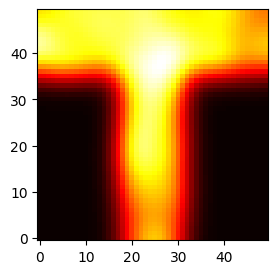

In [39]:
ratemap_sum = all_ratemaps.sum(axis=0)

fig, ax = plt.subplots()
fig.set_size_inches(3, 3)

plt.imshow(ratemap_sum, cmap='hot', origin='lower')

plt.show()

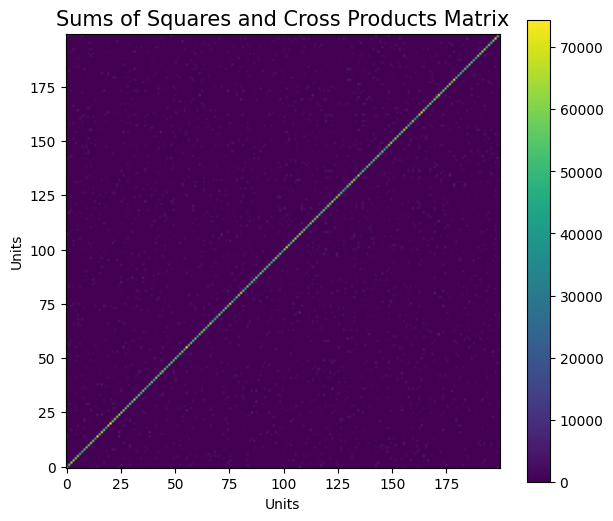

In [40]:
sscp = np.dot(embeddings.T, embeddings)

fig = plt.figure(figsize=(7,6))
plt.title('Sums of Squares and Cross Products Matrix', fontsize=15)
plt.imshow(sscp, origin='lower')
plt.xlabel('Units')
plt.ylabel('Units')
plt.colorbar()
plt.show()

In [41]:
from ae_model.plotting import format_centroids, plot_single_ratemap_density

# Define fields, centroids and sizes
peak_as_centroid=True
min_pix_cluster=0.02 #0.02
max_pix_cluster=0.5 #0.5
active_threshold=0.2 #0.2

all_num_fields, centroids, sizes = stats_place_fields(all_ratemaps, peak_as_centroid=peak_as_centroid, min_pix_cluster=min_pix_cluster, max_pix_cluster=max_pix_cluster, active_threshold=active_threshold)
centroids_per_field, sizes_per_field = format_centroids(all_num_fields, centroids, sizes)

Cell Id: 151
Number of place fields = 1
Size of place fields = [97]
YX position of place fields = [[39, 48]]


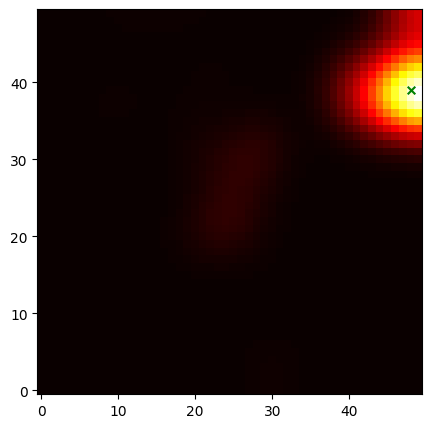

In [42]:
cell_id = np.random.randint(all_ratemaps.shape[0])
print(f'Cell Id: {cell_id}')
unit = np.random.randint(cell_id)
plot_single_ratemap_density(all_ratemaps, unit, all_num_fields, sizes_per_field, centroids_per_field, '', figsize=(5,5), save=False)

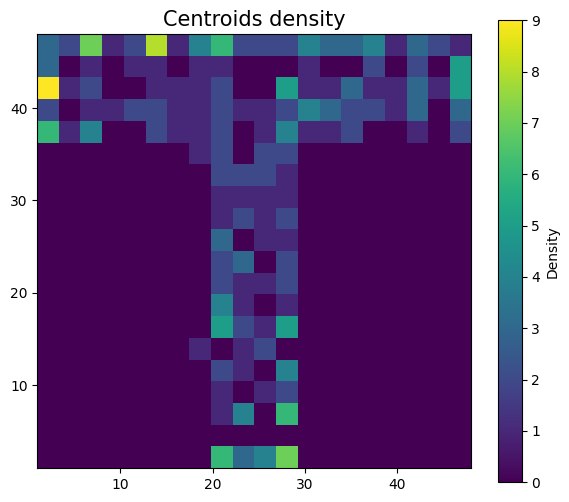

In [43]:
heatmap, xedges, yedges = np.histogram2d(centroids[:,1], centroids[:,0], bins=(20, 20))
extent = [xedges[0], xedges[-1], yedges[0], yedges[-1]]

fig = plt.figure(figsize=(7,6))
plt.imshow(heatmap.T, extent=extent, origin='lower', cmap='viridis')
plt.colorbar(label='Density')
plt.title('Centroids density', fontsize=15)
plt.show()

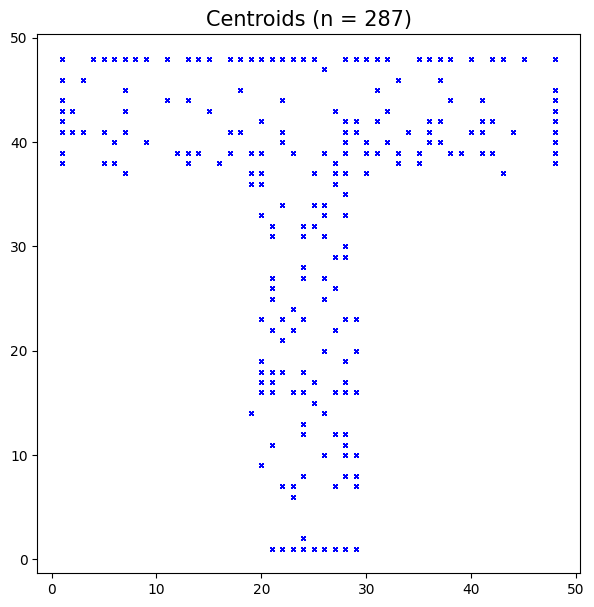

In [44]:
fig = plt.figure(figsize=(7,7))
for i in range(len(centroids)):
    plt.plot(centroids[:,1], centroids[:,0], 'bx', markersize=3)
plt.title("Centroids (n = " + str(len(centroids)) + ")", fontsize=15)
plt.show()

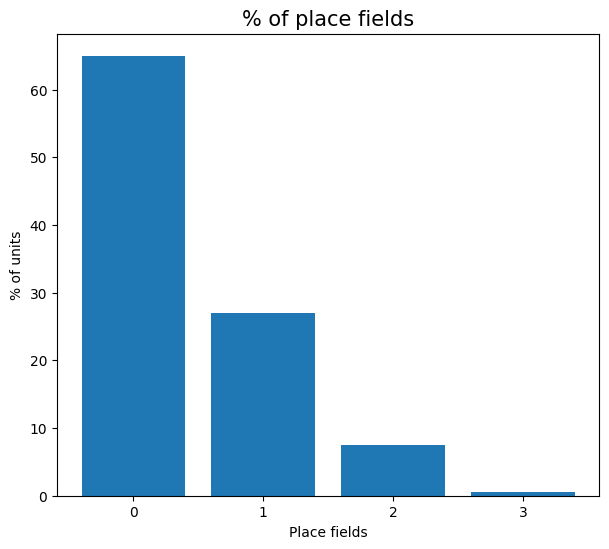

In [45]:
zero_pf = (np.unique(all_num_fields, return_counts=True)[1][0] / n_hidden) * 100
one_pf = (np.unique(all_num_fields, return_counts=True)[1][1] / n_hidden) * 100
two_pf = (np.unique(all_num_fields, return_counts=True)[1][2] / n_hidden) * 100
three_pf = (np.unique(all_num_fields, return_counts=True)[1][3] / n_hidden) * 100

categories = ['0', '1', '2', '3']
values = [zero_pf, one_pf, two_pf, three_pf]

fig = plt.figure(figsize=(7,6))
plt.bar(categories, values)
plt.title('% of place fields', fontsize=15)
plt.xlabel('Place fields')
plt.ylabel('% of units')
plt.show()

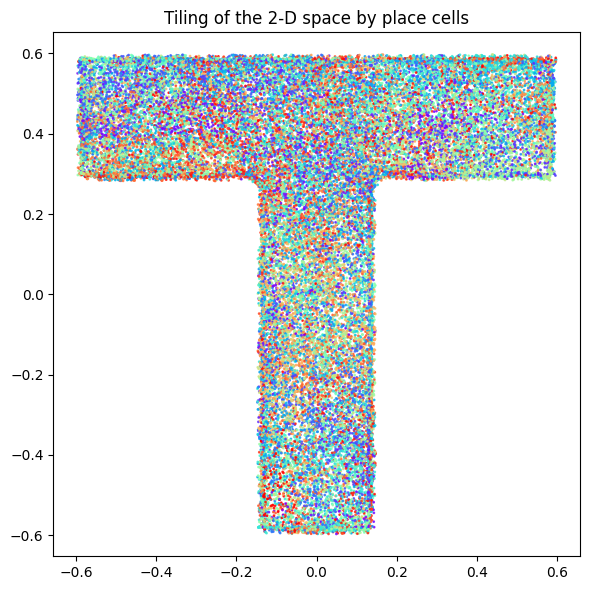

In [46]:
plt.figure(figsize=(6, 6))

plt.subplot(111)
plt.scatter(positions[:, 0], positions[:, 1], c=labels, cmap='rainbow', s=1, alpha=0.8)

# plt.scatter(prototypes[:, 0], prototypes[:, 1], marker='X', s=200, edgecolors='k', facecolors='none', linewidths=1.5)
plt.title("Tiling of the 2‑D space by place cells")
plt.axis('equal')


plt.tight_layout()
plt.show()